# Prediksi Resistensi Fenotipe dalam setiap Antibiotik terhadap Bakteri

## Abstraksi

## Import Library

In [310]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_selection import chi2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from utilities.utility import AMRDataPipeline
from imblearn.over_sampling import SMOTE

from scipy.spatial.distance import squareform, pdist
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor, DistanceMatrix
from Bio import Phylo

RANDOM_STATE = 42

### Helper Function

In [311]:
def notebook_visualize_unitigs_over_time(X_original, metadata_path, fitur_terpilih, antibiotic_col='azm', unitigs=5):
    meta = pd.read_csv(metadata_path)
    meta = meta.dropna(subset=[f'{antibiotic_col}_sr'])
    meta[f'{antibiotic_col}_sr'] = meta[f'{antibiotic_col}_sr'].astype(int)
    meta = meta[meta[f'{antibiotic_col}_sr'].isin([0, 1])]
    meta.set_index('Sample_ID', inplace=True)
    
    unitigs_sequences = fitur_terpilih[:unitigs]
    
    unitig_time_df = X_original[unitigs_sequences].join(meta[['Year', f'{antibiotic_col}_sr']], how="inner")
    
    unitig_filtered_resistance_df = unitig_time_df[unitig_time_df[f'{antibiotic_col}_sr'] == 1]
    unitig_filtered_succeptible_df = unitig_time_df[unitig_time_df[f'{antibiotic_col}_sr'] == 0]

    unitig_mean_resistance = unitig_filtered_resistance_df.groupby('Year').mean().sort_index()
    unitig_mean_succeptible = unitig_filtered_succeptible_df.groupby('Year').mean().sort_index()
    
    plt.figure(figsize=(12, 6))
    plt.title(f"Unitig Sequence Trajectory of Gonorhea ({antibiotic_col.upper()})")

    for unitig in unitigs_sequences:
        line, = plt.plot(unitig_mean_resistance.index, unitig_mean_resistance[unitig], marker='o', linestyle='-', alpha=1.0, label=f"{unitig[:10]}... (Resistant)")
        shared_color = line.get_color()
        plt.plot(unitig_mean_succeptible.index, unitig_mean_succeptible[unitig], marker='x', linestyle='--', alpha=0.3, color=shared_color, label=f"{unitig[:10]}... (Susceptible)")

    plt.grid(True, alpha=0.5, linestyle='--')
    plt.ylabel("Unitig Frequency")
    plt.xlabel("Timeline")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [312]:
def notebook_visualize_phylo_tree(X_clean, y, unitigs=15, mode='ascii', type='resistant'):
    df_temp = X_clean.copy()
    df_temp['target'] = y
    
    if type == 'resistant':
        df = df_temp[df_temp['target'] == 1].iloc[:unitigs].drop(columns=['target'])
    elif type == 'succeptible':
        df = df_temp[df_temp['target'] == 0].iloc[:unitigs].drop(columns=['target'])
    else:
        raise ValueError(f"{type} is not supported.")\
    
    names = [str(name) for name in df.index.tolist()]
    dense_matrix = squareform(pdist(df.values, metric='jaccard'))
    
    biopython_matrix = []
    for i in range(len(names)):
        row = list(dense_matrix[i, :i+1])
        biopython_matrix.append(row)

    dm = DistanceMatrix(names=names, matrix=biopython_matrix)
    constructor = DistanceTreeConstructor()
    tree = constructor.nj(dm)
    
    if mode == 'plt':
        plt.figure(figsize=(20, 12))
        Phylo.draw(tree, do_show=False)
        plt.title(f"Phylogenetic Tree - {type.capitalize()} Samples")
        plt.show()
    elif mode == 'ascii':
        Phylo.draw_ascii(tree)
    

# 3. Testing for All Features

In [313]:
X_azm_real_feature = pd.read_csv("data/azm_real_features.csv", sep="\t").set_index("Sample_ID")
y_azm_real_label = pd.read_csv("data/azm_real_labels.csv", sep="\t").set_index("Sample_ID").squeeze()


In [314]:

X_train, X_test, y_train, y_test = train_test_split(
    X_azm_real_feature, y_azm_real_label, test_size=0.2, random_state=RANDOM_STATE, stratify=y_azm_real_label
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test
)
print(f"\nTraining set : {X_train.shape[0]} rows")
print(f"Validation set : {X_val.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")


Training set : 2782 rows
Validation set : 348 rows
Test set     : 348 rows


### Handling Imbalanced Dataset

In [315]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nResampled training set : {X_train_resampled.shape[0]} rows") 



Resampled training set : 4848 rows


### Random Forest Feature Selection

In [316]:
rf_ori_model = RandomForestClassifier(
    n_estimators=250,         
    max_depth=8,               
    class_weight='balanced',   
    random_state=RANDOM_STATE,
    n_jobs=-1                  
)
rf_ori_model.fit(X_train_resampled, y_train_resampled)
y_val_pred_real_rf = rf_ori_model.predict(X_val)


d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-le

In [317]:

print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_val_pred_real_rf))
print("Classification Report:\n", classification_report(y_val, y_val_pred_real_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_real_rf))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_real_rf).value_counts())


Random Forest Validation Accuracy: 0.8706896551724138
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93       303
           1       0.50      0.53      0.52        45

    accuracy                           0.87       348
   macro avg       0.72      0.73      0.72       348
weighted avg       0.87      0.87      0.87       348

Confusion Matrix:
 [[279  24]
 [ 21  24]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    300
1     48
Name: count, dtype: int64


### Support Vector Machine

In [318]:
sv_real_model = SVC(
    kernel='rbf',              
    C=1.0,                    
    class_weight='balanced',   
    random_state=RANDOM_STATE
)
sv_real_model.fit(X_train_resampled, y_train_resampled)
y_val_pred_real_sv = sv_real_model.predict(X_val)




In [319]:
print("SVM Validation Accuracy:", accuracy_score(y_val, y_val_pred_real_sv))
print("Classification Report:\n", classification_report(y_val, y_val_pred_real_sv))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_real_sv))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_real_sv).value_counts())

SVM Validation Accuracy: 0.8735632183908046
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93       303
           1       0.51      0.53      0.52        45

    accuracy                           0.87       348
   macro avg       0.72      0.73      0.72       348
weighted avg       0.88      0.87      0.87       348

Confusion Matrix:
 [[280  23]
 [ 21  24]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    301
1     47
Name: count, dtype: int64


### XGBoost

In [320]:
xgb_real_model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    scale_pos_weight=1,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_real_model.fit(X_train_resampled, y_train_resampled)
y_val_pred_real_xgb = xgb_real_model.predict(X_val)




d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:50:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [321]:
print("XGBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred_real_xgb))
print("Classification Report:\n", classification_report(y_val, y_val_pred_real_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_real_xgb))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_real_sv).value_counts())

XGBoost Validation Accuracy: 0.8793103448275862
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       303
           1       0.53      0.62      0.57        45

    accuracy                           0.88       348
   macro avg       0.74      0.77      0.75       348
weighted avg       0.89      0.88      0.88       348

Confusion Matrix:
 [[278  25]
 [ 17  28]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    301
1     47
Name: count, dtype: int64


# 4. Testing for Selected Feature

In [322]:
X_azm_feature = pd.read_csv("data/azm_features.csv", sep="\t").set_index("Sample_ID")
y_azm_label = pd.read_csv("data/azm_labels.csv", sep="\t").set_index("Sample_ID").squeeze()


In [323]:

X_train, X_test, y_train, y_test = train_test_split(
    X_azm_feature, y_azm_label, test_size=0.2, random_state=RANDOM_STATE, stratify=y_azm_label
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test
)
print(f"\nTraining set : {X_train.shape[0]} rows")
print(f"Validation set : {X_val.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")


Training set : 2782 rows
Validation set : 348 rows
Test set     : 348 rows


### Handling Imbalanced Dataset

In [324]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nResampled training set : {X_train_resampled.shape[0]} rows") 



Resampled training set : 4848 rows


### Random Forest

In [325]:
rf_model = RandomForestClassifier(
    n_estimators=250,         
    max_depth=8,               
    class_weight='balanced',   
    random_state=RANDOM_STATE,
    n_jobs=-1                  
)
rf_model.fit(X_train_resampled, y_train_resampled)
y_val_pred_real_rf = rf_model.predict(X_val)


d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-le

In [326]:

print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_val_pred_real_rf))
print("Classification Report:\n", classification_report(y_val, y_val_pred_real_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_real_rf))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_real_rf).value_counts())


Random Forest Validation Accuracy: 0.9655172413793104
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       303
           1       0.87      0.87      0.87        45

    accuracy                           0.97       348
   macro avg       0.92      0.92      0.92       348
weighted avg       0.97      0.97      0.97       348

Confusion Matrix:
 [[297   6]
 [  6  39]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    303
1     45
Name: count, dtype: int64


### SVM Model

In [327]:
sv_model = SVC(
    kernel='rbf',              
    C=1.0,                    
    class_weight='balanced',   
    random_state=RANDOM_STATE
)
sv_model.fit(X_train_resampled, y_train_resampled)
y_val_pred_real_sv = sv_model.predict(X_val)




In [328]:
print("SVM Validation Accuracy:", accuracy_score(y_val, y_val_pred_real_sv))
print("Classification Report:\n", classification_report(y_val, y_val_pred_real_sv))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_real_sv))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_real_sv).value_counts())

SVM Validation Accuracy: 0.9683908045977011
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       303
           1       0.83      0.96      0.89        45

    accuracy                           0.97       348
   macro avg       0.91      0.96      0.93       348
weighted avg       0.97      0.97      0.97       348

Confusion Matrix:
 [[294   9]
 [  2  43]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    296
1     52
Name: count, dtype: int64


### XGBoost

In [329]:
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    scale_pos_weight=1,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_val_pred_real_xgb = xgb_model.predict(X_val)




d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:50:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [330]:
print("XGBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred_real_xgb))
print("Classification Report:\n", classification_report(y_val, y_val_pred_real_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_real_xgb))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_real_xgb).value_counts())


XGBoost Validation Accuracy: 0.9626436781609196
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       303
           1       0.83      0.89      0.86        45

    accuracy                           0.96       348
   macro avg       0.91      0.93      0.92       348
weighted avg       0.96      0.96      0.96       348

Confusion Matrix:
 [[295   8]
 [  5  40]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    300
1     48
Name: count, dtype: int64


# 6. Visualization on Evaluation

In [331]:
X = X_azm_feature.copy()
top_features = X.columns.tolist()

### Visualization Unitigs Over The Years 

#### Chi-Square Feature Selection

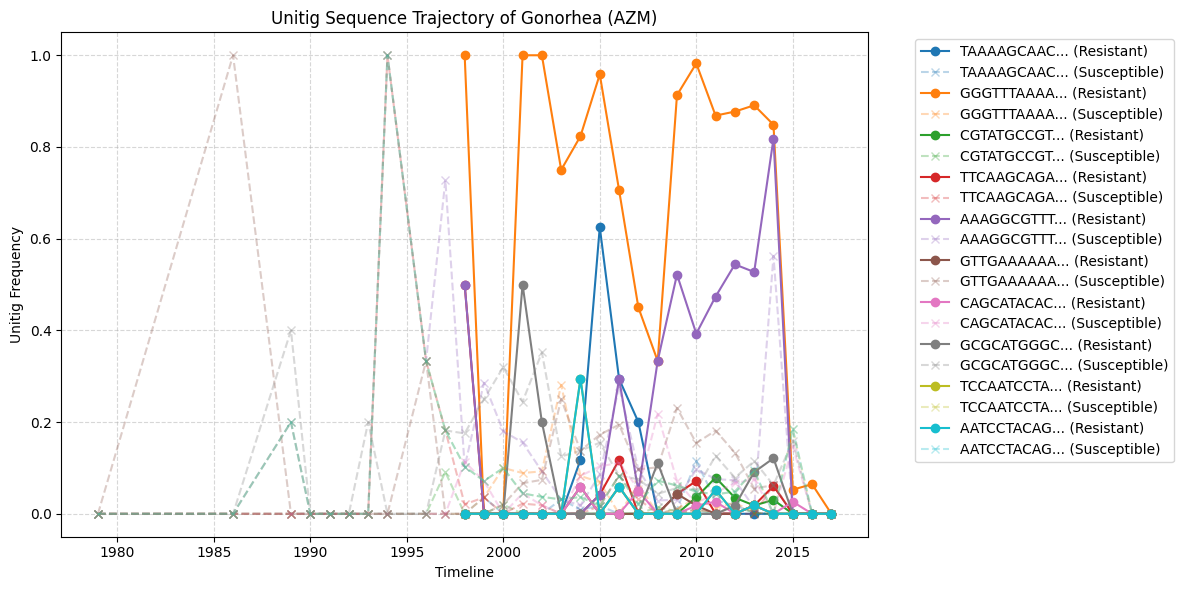

In [332]:
notebook_visualize_unitigs_over_time(
    X_original=X, 
    metadata_path="data/metadata.csv", 
    fitur_terpilih=top_features, 
    antibiotic_col='azm', 
    unitigs=10 
)

### Visualization Phylo Tree

#### Chi-Square Feature Selection

In [333]:
notebook_visualize_phylo_tree(
    X_clean=X_train_resampled, 
    y=y_train_resampled, 
    unitigs=50,       
    mode='ascii',   
    type='resistant'  
)

         ____ 385
        |
     ___|______ 277
    |   |
   ,|   |____ 122
   ||
   || , 233
   ||_|
   |  | 102
   |
   |     _______ 239
   |    |
   |    |              __ 371
   |    |            ,|
   |    |            ||_______ 245
   |    |      ______|
  _|    |     |      |            , 320
 | |    |     |      |           _|
 | |    |     |      |__________| | 249
 | |    |     |                 |
 | |    |     |                 | 183
 | |    |     |
 | |    |    _|          _______________________ 117
 | |    |   | |         |
 | |    |   | |         |     _____________________ 398
 | |    |   | |         |    |
 | |    |   | |         |   _|       ________________ 64
 | |    |   | |         |  | |      |
 | |____|   | |         |  | |      |                  _______ 255
 |      |   | |_________|  | |______|                 |
 |      |   |           |  |        |                 |     , 285
 |      |   |           |  |        |                 |   __|
 |      |   |         

# 7. Export Model

### Random Forest

In [334]:

joblib.dump(rf_model, 'model/rf_model.pkl')

['model/rf_model.pkl']

### SVM Model

In [335]:
joblib.dump(sv_model, 'model/svm_model.pkl')

['model/svm_model.pkl']

### XGBoost Model (The Best Model)

In [336]:
XGBoost_model = xgb_model
XGBoost_model.save_model('model/best_xgboost_model.json')


# 8. Load Model

In [338]:
load_xgb_model = XGBClassifier()

load_xgb_model.load_model("model/best_xgboost_model.json")
model_features = load_xgb_model.feature_names_in_
X_test = X_test.reindex(columns=model_features, fill_value=0)
y_pred_xgb = load_xgb_model.predict(X_test)

print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("True Class:\n", y_test.value_counts())

print("Predicted Class:\n", pd.Series(y_pred_xgb).value_counts())




XGBoost Test Accuracy: 0.9626436781609196
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       304
           1       0.92      0.77      0.84        44

    accuracy                           0.96       348
   macro avg       0.94      0.88      0.91       348
weighted avg       0.96      0.96      0.96       348

Confusion Matrix:
 [[301   3]
 [ 10  34]]
True Class:
 azm_sr
0    304
1     44
Name: count, dtype: int64
Predicted Class:
 0    311
1     37
Name: count, dtype: int64


In [339]:
df_result = pd.DataFrame({
    'Actual_Status': y_test,                   
    'Predicted_Status': y_pred_xgb         
}, index=X_test.index)

print(df_result.head(348))

            Actual_Status  Predicted_Status
Sample_ID                                  
17150_8#53              0                 0
17428_6#41              0                 0
ERR2172325              1                 1
15335_4#61              0                 0
17150_2#38              0                 0
...                   ...               ...
15335_6#15              0                 0
17328_4#80              0                 0
15335_7#75              0                 0
16933_3#80              0                 0
15335_3#74              0                 0

[348 rows x 2 columns]


In [340]:
model_to_csv = df_result.copy()
model_to_csv.to_csv('data/azm_labels_prediction.csv', index=True)